# Customer Churn Analysis & Machine Learning Prediction
## Complete End-to-End Data Science Project

### Project Overview
Customer churn is one of the most critical metrics for subscription and SaaS businesses. Retaining an existing customer is significantly cheaper than acquiring a new one. This project builds an end-to-end Machine Learning pipeline to predict customer churn, identify key risk drivers (e.g., payment delays, high support calls, contract types), and evaluate models using business-critical metrics.

---

### Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Visual Styling
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'Arial'

### Step 2: Load Dataset & Inspect Schema

In [2]:
df = pd.read_csv('customer.csv')
print("Original Dataset Shape:", df.shape)
df.head()

Original Dataset Shape: (2500, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,CUST-10000,56.0,Male,12.0,27.0,4.0,1.0,Standard,Monthly,761.35,22.0,0.0
1,CUST-10001,46.0,Female,37.0,13.0,1.0,1.0,Basic,Monthly,3130.78,27.0,0.0
2,CUST-10002,32.0,Female,28.0,19.0,4.0,1.0,Standard,Monthly,2699.87,9.0,0.0
3,CUST-10003,60.0,Female,20.0,21.0,3.0,5.0,Premium,Monthly,1940.70,7.0,0.0
4,CUST-10004,25.0,Female,39.0,24.0,3.0,17.0,Standard,Quarterly,3362.43,5.0,1.0


### Step 3: Data Quality Audit & Cleaning

In [3]:
print("--- Missing Values Per Column ---")
print(df.isnull().sum())

# Handle missing data by dropping incomplete records
df_clean = df.dropna().copy()

# Ensure numeric casting
num_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']
for col in num_cols:
    df_clean[col] = pd.to_numeric(df_clean[col])

df_clean['Churn'] = pd.to_numeric(df_clean['Churn']).astype(int)
print("\nCleaned Dataset Shape:", df_clean.shape)

--- Missing Values Per Column ---
CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

Cleaned Dataset Shape: (2499, 12)


### Step 4: Exploratory Data Analysis (EDA)
Visualizing patterns between customer behavior and churn status.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16392\669522646.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(['Retained', 'Churned'])


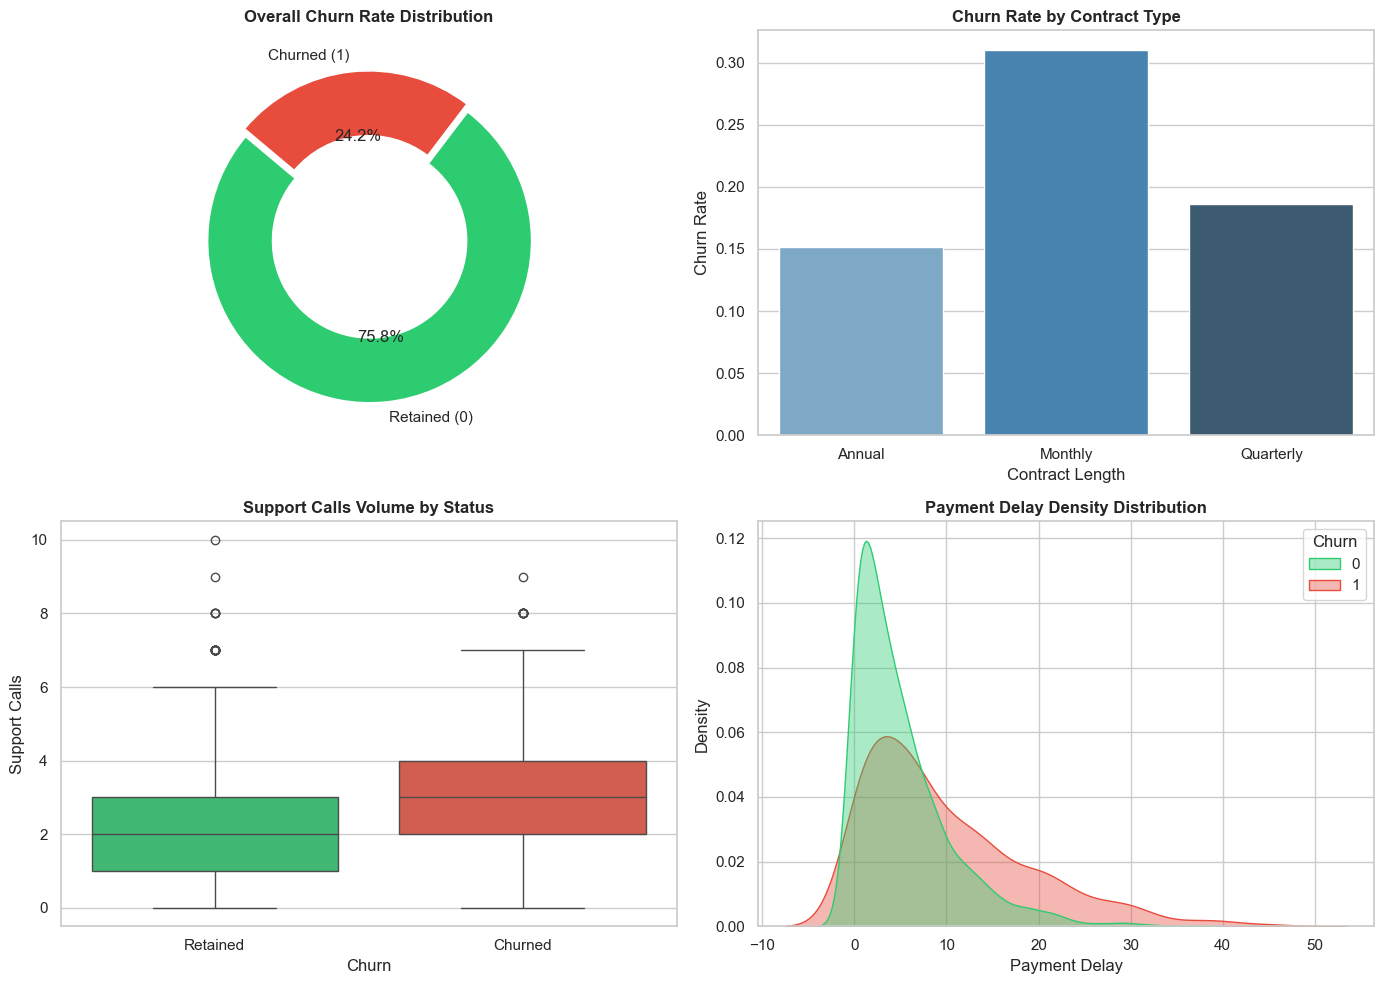

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Churn Rate Distribution
churn_counts = df_clean['Churn'].value_counts()
axes[0, 0].pie(churn_counts, labels=['Retained (0)', 'Churned (1)'], autopct='%1.1f%%',
               startangle=140, colors=['#2ecc71', '#e74c3c'], explode=(0.05, 0), wedgeprops=dict(width=0.4))
axes[0, 0].set_title('Overall Churn Rate Distribution', fontsize=12, fontweight='bold')

# 2. Contract Length vs Churn
contract_churn = df_clean.groupby('Contract Length')['Churn'].mean().reset_index()
sns.barplot(data=contract_churn, x='Contract Length', y='Churn', hue='Contract Length', palette='Blues_d', ax=axes[0, 1], legend=False)
axes[0, 1].set_title('Churn Rate by Contract Type', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Churn Rate')

# 3. Support Calls vs Churn
sns.boxplot(data=df_clean, x='Churn', y='Support Calls', hue='Churn', palette=['#2ecc71', '#e74c3c'], ax=axes[1, 0], legend=False)
axes[1, 0].set_xticklabels(['Retained', 'Churned'])
axes[1, 0].set_title('Support Calls Volume by Status', fontsize=12, fontweight='bold')

# 4. Payment Delay Distribution
sns.kdeplot(data=df_clean, x='Payment Delay', hue='Churn', common_norm=False, palette=['#2ecc71', '#e74c3c'], fill=True, alpha=0.4, ax=axes[1, 1])
axes[1, 1].set_title('Payment Delay Density Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Step 5: Feature Encoding & Correlation Analysis

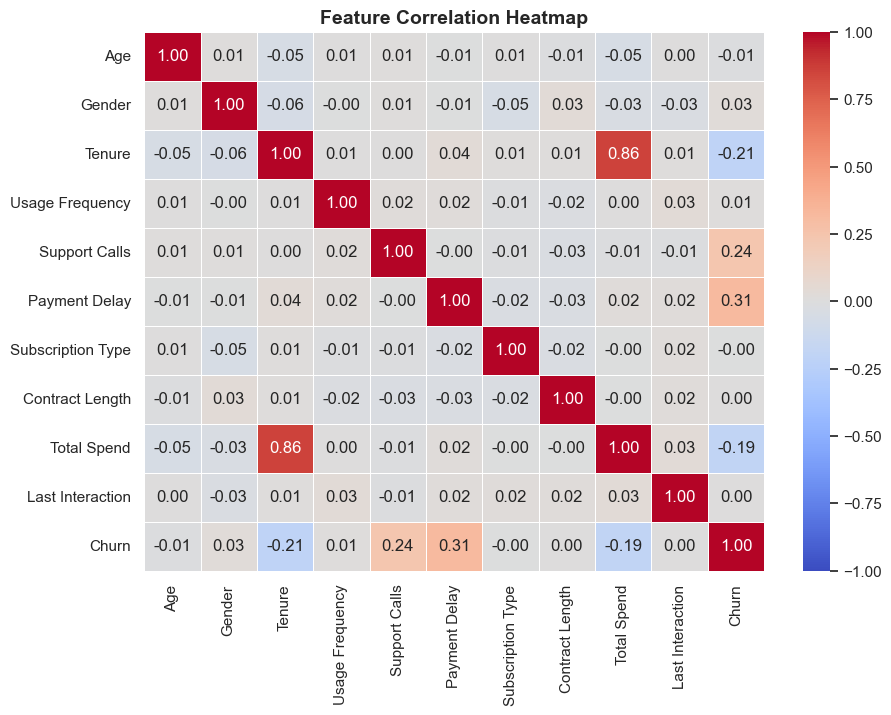

In [5]:
df_encoded = df_clean.drop(columns=['CustomerID']).copy()

# Categorical Encoding using independent LabelEncoders
encoders = {}
cat_cols = ['Gender', 'Subscription Type', 'Contract Length']
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoders[col] = le

# Correlation Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

### Step 6: Train-Test Split & Feature Scaling

In [6]:
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# Stratified 70/30 Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Feature scaling for linear models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (1749, 10)
Testing set shape: (750, 10)


### Step 7: Model Training & Evaluation Matrix

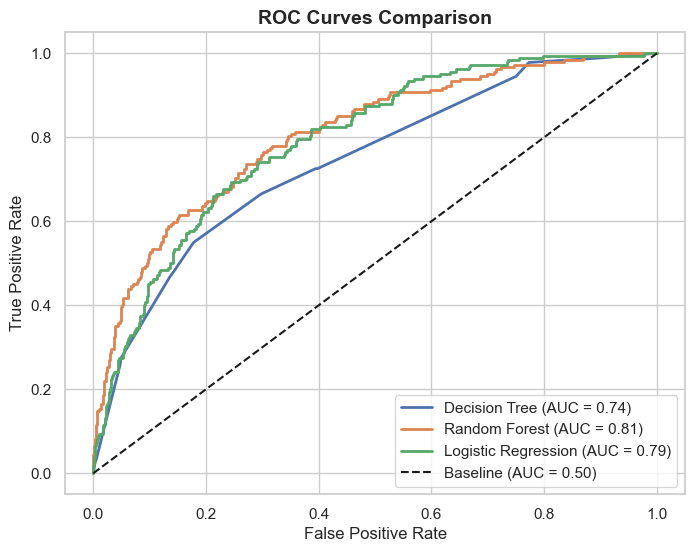


--- Model Performance Comparison Table ---
                     Accuracy Precision    Recall  F1-Score   ROC-AUC
Decision Tree        0.693333  0.417241  0.664835  0.512712  0.743253
Random Forest        0.738667  0.472868   0.67033  0.554545  0.806928
Logistic Regression  0.734667  0.468401  0.692308  0.558758  0.793859


In [7]:
models = {
    'Decision Tree': DecisionTreeClassifier(criterion='entropy', max_depth=4, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=6, class_weight='balanced', random_state=42),
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42)
}

results = {}

plt.figure(figsize=(8, 6))
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results[name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc,
        'y_pred': y_pred, 'y_prob': y_prob
    }
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Baseline (AUC = 0.50)')
plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Display Performance Table
results_df = pd.DataFrame(results).T[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']]
print("\n--- Model Performance Comparison Table ---")
print(results_df.round(4))

### Step 8: Confusion Matrix Analysis

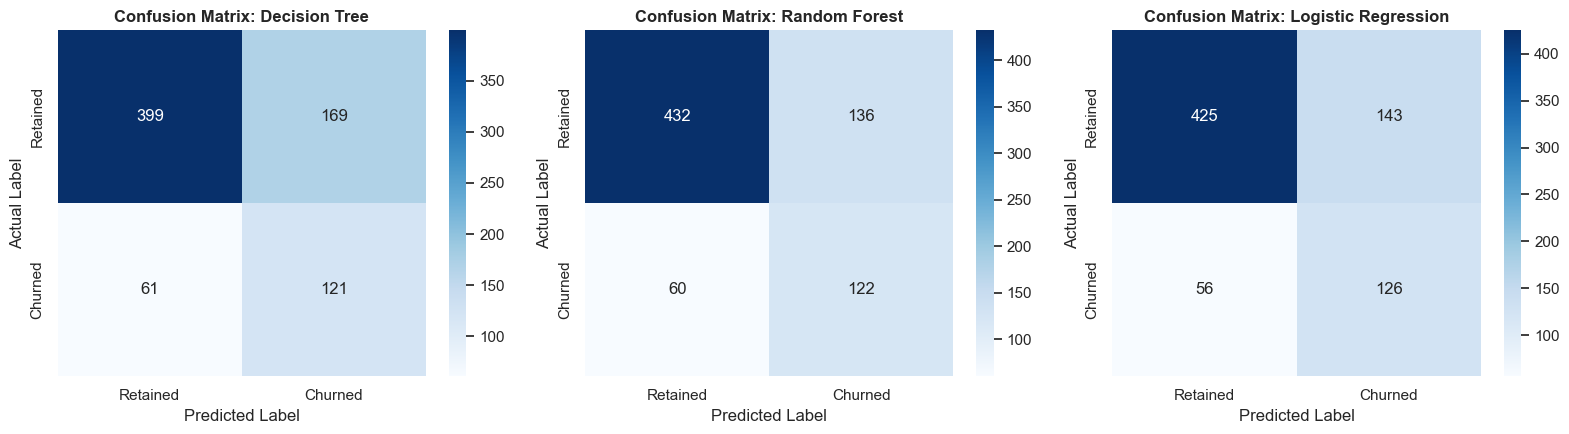

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
    axes[idx].set_title(f'Confusion Matrix: {name}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Actual Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

### Step 9: Feature Importance & Business Insights

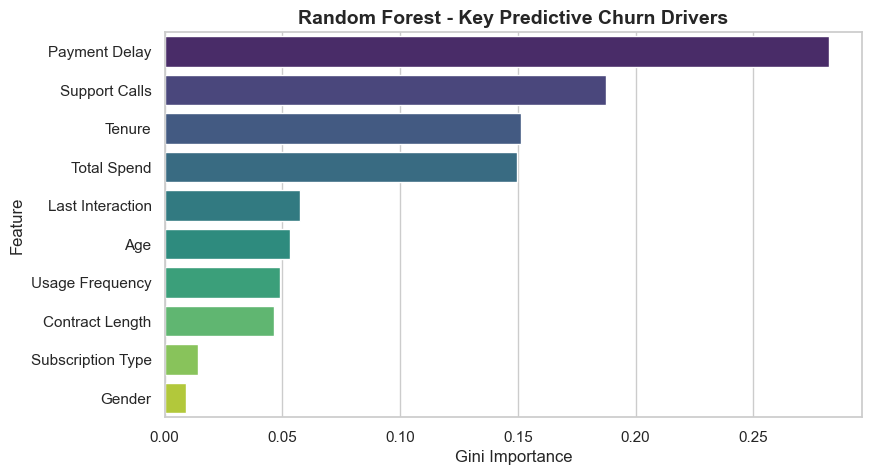

Top 5 Critical Predictors:
            Feature  Importance
5     Payment Delay    0.282154
4     Support Calls    0.187319
2            Tenure    0.151327
8       Total Spend    0.149654
9  Last Interaction    0.057300


In [9]:
rf_model = models['Random Forest']
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Random Forest - Key Predictive Churn Drivers', fontsize=14, fontweight='bold')
plt.xlabel('Gini Importance')
plt.show()

print("Top 5 Critical Predictors:")
print(importance_df.head())

### Step 10: Decision Tree Visualization

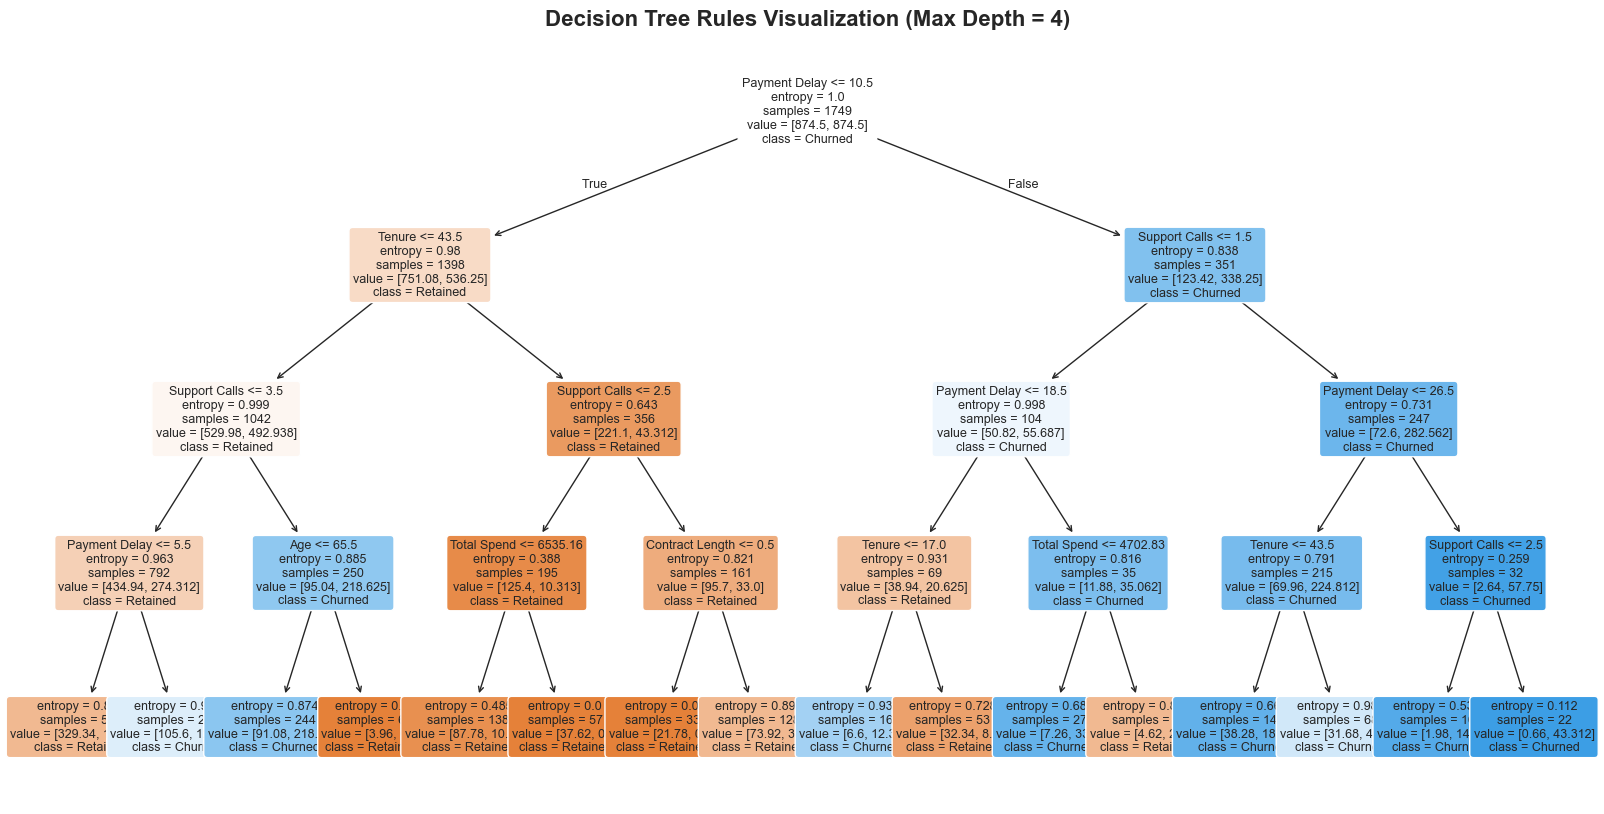

In [10]:
plt.figure(figsize=(20, 10))
plot_tree(
    models['Decision Tree'],
    feature_names=X.columns,
    class_names=['Retained', 'Churned'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Decision Tree Rules Visualization (Max Depth = 4)', fontsize=16, fontweight='bold')
plt.show()

### Step 11: Single Customer Inference Pipeline

In [11]:
def predict_customer_churn(sample_dict):
    sample_df = pd.DataFrame([sample_dict])
    for col in cat_cols:
        sample_df[col] = encoders[col].transform(sample_df[col])
    prob = models['Random Forest'].predict_proba(sample_df)[0][1]
    status = "HIGH CHURN RISK" if prob >= 0.50 else "LOW CHURN RISK"
    return status, round(prob * 100, 2)

# Test Sample Customer
test_customer = {
    'Age': 45,
    'Gender': 'Female',
    'Tenure': 5,
    'Usage Frequency': 4,
    'Support Calls': 6,
    'Payment Delay': 18,
    'Subscription Type': 'Basic',
    'Contract Length': 'Monthly',
    'Total Spend': 350.0,
    'Last Interaction': 22
}

risk_status, risk_pct = predict_customer_churn(test_customer)
print(f"Inference Result: {risk_status} ({risk_pct}% probability of churn)")

Inference Result: HIGH CHURN RISK (81.98% probability of churn)
